# KMeans Clustering on ECG200

This notebook loads ECG200 time-series data from UCR, applies KMeans clustering, and compares discovered clusters to known class labels.

In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mitigates common MKL warning for KMeans on Windows
os.environ.setdefault('OMP_NUM_THREADS', '1')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    accuracy_score,
    )
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

In [9]:
# Resolve UCR root for common local layouts
root_candidates = [
    (Path('..') / '..' / 'data' / 'UCRArchive_2018').resolve(),
    (Path('..') / '..' / 'data' / 'UCRArchive_2018' / 'UCRArchive_2018').resolve(),
]
UCR_ROOT = next((p for p in root_candidates if p.exists()), root_candidates[0])

dataset_name = 'ECG200'
train_path = UCR_ROOT / dataset_name / f'{dataset_name}_TRAIN.tsv'
test_path = UCR_ROOT / dataset_name / f'{dataset_name}_TEST.tsv'

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        f'Could not find ECG200 files. Checked: {train_path} and {test_path}'
    )

train_df = pd.read_csv(train_path, sep='\t', header=None)
test_df = pd.read_csv(test_path, sep='\t', header=None)
df = pd.concat([train_df, test_df], ignore_index=True)

y_true = df.iloc[:, 0].to_numpy()
X = df.iloc[:, 1:].to_numpy()

print('UCR root:', UCR_ROOT)
print('Dataset:', dataset_name)
print('Samples x Features:', X.shape)
print('Classes:', np.unique(y_true))

UCR root: D:\repositories\personal\xai-spatio-temporal\data\UCRArchive_2018
Dataset: ECG200
Samples x Features: (200, 96)
Classes: [-1  1]


Per-series mean (avg +/- std): 0.0 +/- 0.0
Per-series std  (avg +/- std): 0.9948 +/- 0.0


d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

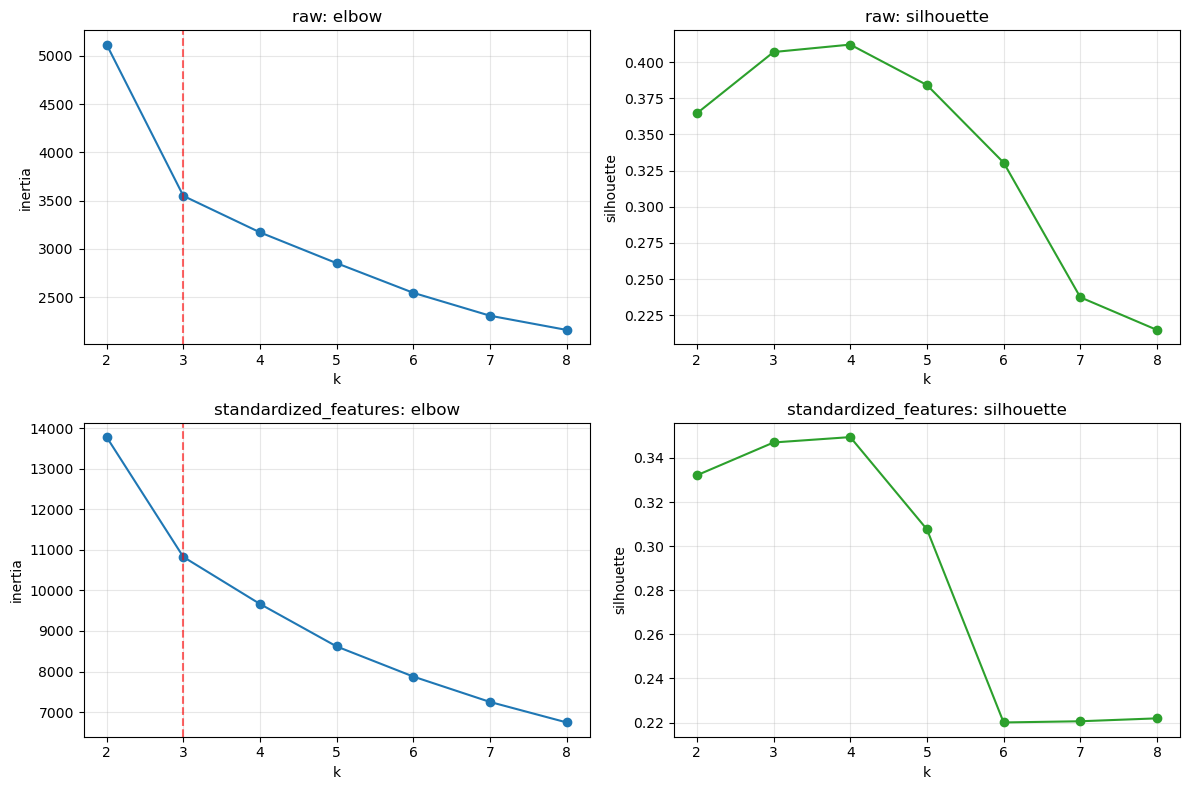

,view,k,silhouette,calinski_harabasz,davies_bouldin,stability_ari,elbow_k,rank_sum
0,raw,3,0.406905,114.971914,1.089663,0.987186,3,7.5
1,raw,4,0.412036,93.310579,1.018638,0.974119,3,8.0
2,standardized_features,3,0.347004,76.224264,1.325768,1.000000,3,8.5
3,standardized_features,4,0.349440,64.655234,1.241029,0.806966,3,10.0
4,standardized_features,2,0.332130,77.961689,1.339070,1.000000,3,10.0
5,raw,2,0.364550,99.681045,1.104280,1.000000,3,11.0
6,raw,5,0.384092,82.944745,1.055688,0.902587,3,15.0
7,standardized_features,5,0.307594,59.902927,1.317537,0.757800,3,17.0
8,standardized_features,8,0.221891,50.871030,1.300736,0.827301,3,18.0
9,raw,6,0.330456,78.535825,1.211527,0.971985,3,19.0


Selected preprocessing: raw
Selected k: 3


In [10]:
# Check whether each time series already looks z-normalized
row_means = X.mean(axis=1)
row_stds = X.std(axis=1, ddof=0)
print('Per-series mean (avg +/- std):', round(float(row_means.mean()), 4), '+/-', round(float(row_means.std()), 4))
print('Per-series std  (avg +/- std):', round(float(row_stds.mean()), 4), '+/-', round(float(row_stds.std()), 4))

# Compare raw values vs feature-wise standardization
views = {
    'raw': X,
    'standardized_features': StandardScaler().fit_transform(X),
}

k_values = list(range(2, 9))
seed_list = [0, 1, 2, 3, 4]

def elbow_k_from_line(k_list, inertia_list):
    x = np.asarray(k_list, dtype=float)
    y = np.asarray(inertia_list, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line = p2 - p1
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        return int(k_list[0])
    distances = []
    for i in range(len(x)):
        p = np.array([x[i], y[i]])
        distances.append(np.abs(np.cross(line, p - p1)) / line_norm)
    return int(k_list[int(np.argmax(distances))])

rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (view_name, X_view) in enumerate(views.items()):
    inertias = []
    silhouettes = []
    ch_scores = []
    db_scores = []
    stabilities = []

    for k in k_values:
        labels_by_seed = []
        inertias_by_seed = []
        for seed in seed_list:
            km = KMeans(n_clusters=k, random_state=seed, n_init=20)
            labels = km.fit_predict(X_view)
            labels_by_seed.append(labels)
            inertias_by_seed.append(km.inertia_)

        base_labels = labels_by_seed[0]
        inertias.append(float(np.mean(inertias_by_seed)))
        silhouettes.append(float(silhouette_score(X_view, base_labels)))
        ch_scores.append(float(calinski_harabasz_score(X_view, base_labels)))
        db_scores.append(float(davies_bouldin_score(X_view, base_labels)))

        pairwise_ari = []
        for i in range(len(labels_by_seed)):
            for j in range(i + 1, len(labels_by_seed)):
                pairwise_ari.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))
        stabilities.append(float(np.mean(pairwise_ari)))

    elbow_k = elbow_k_from_line(k_values, inertias)

    for i, k in enumerate(k_values):
        rows.append({
            'view': view_name,
            'k': k,
            'inertia': inertias[i],
            'silhouette': silhouettes[i],
            'calinski_harabasz': ch_scores[i],
            'davies_bouldin': db_scores[i],
            'stability_ari': stabilities[i],
            'elbow_k': elbow_k,
            'elbow_match': int(k == elbow_k),
        })

    axes[idx, 0].plot(k_values, inertias, marker='o')
    axes[idx, 0].axvline(elbow_k, color='r', linestyle='--', alpha=0.6)
    axes[idx, 0].set_title(f'{view_name}: elbow')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('inertia')
    axes[idx, 0].grid(alpha=0.3)

    axes[idx, 1].plot(k_values, silhouettes, marker='o', color='tab:green')
    axes[idx, 1].set_title(f'{view_name}: silhouette')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('silhouette')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

selection_df = pd.DataFrame(rows)

for metric in ['silhouette', 'calinski_harabasz', 'stability_ari']:
    selection_df[f'rank_{metric}'] = selection_df.groupby('view')[metric].rank(method='dense', ascending=False)
selection_df['rank_davies_bouldin'] = selection_df.groupby('view')['davies_bouldin'].rank(method='dense', ascending=True)

selection_df['rank_sum'] = (
    selection_df['rank_silhouette']
    + selection_df['rank_calinski_harabasz']
    + selection_df['rank_davies_bouldin']
    + selection_df['rank_stability_ari']
    - 0.5 * selection_df['elbow_match']
    )

selection_df = selection_df.sort_values(['rank_sum', 'silhouette'], ascending=[True, False]).reset_index(drop=True)
display(selection_df[['view', 'k', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'stability_ari', 'elbow_k', 'rank_sum']].head(10))

best_view = str(selection_df.loc[0, 'view'])
best_k = int(selection_df.loc[0, 'k'])
print(f'Selected preprocessing: {best_view}')
print(f'Selected k: {best_k}')

In [11]:
# Fit final KMeans with selected preprocessing and selected k
X_used = views[best_view]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_used)

print('Final preprocessing:', best_view)
print('Final k:', best_k)
print('Inertia:', round(float(kmeans.inertia_), 3))
print('Silhouette:', round(float(silhouette_score(X_used, cluster_labels)), 4))
print('Calinski-Harabasz:', round(float(calinski_harabasz_score(X_used, cluster_labels)), 2))
print('Davies-Bouldin:', round(float(davies_bouldin_score(X_used, cluster_labels)), 4))

d:\env\py128\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Final preprocessing: raw
Final k: 3
Inertia: 3549.835
Silhouette: 0.4069
Calinski-Harabasz: 114.97
Davies-Bouldin: 1.0897


In [12]:
# Compare unsupervised clusters against true labels
comparison = pd.DataFrame({'true_label': y_true, 'cluster': cluster_labels})
crosstab = pd.crosstab(comparison['true_label'], comparison['cluster'])

display(crosstab)

majority_mapping = {}
for c in sorted(comparison['cluster'].unique()):
    mode_label = comparison.loc[comparison['cluster'] == c, 'true_label'].mode().iloc[0]
    majority_mapping[c] = mode_label

predicted_by_cluster = np.array([majority_mapping[c] for c in comparison['cluster']])
agreement = (predicted_by_cluster == y_true).mean()

print('Cluster -> label mapping:', majority_mapping)
print('Agreement with true labels (majority-mapped):', round(float(agreement), 4))

cluster,0,1,2
true_label,,,
-1,11,35,21
1,100,19,14


Cluster -> label mapping: {np.int32(0): np.int64(1), np.int32(1): np.int64(-1), np.int32(2): np.int64(-1)}
Agreement with true labels (majority-mapped): 0.78


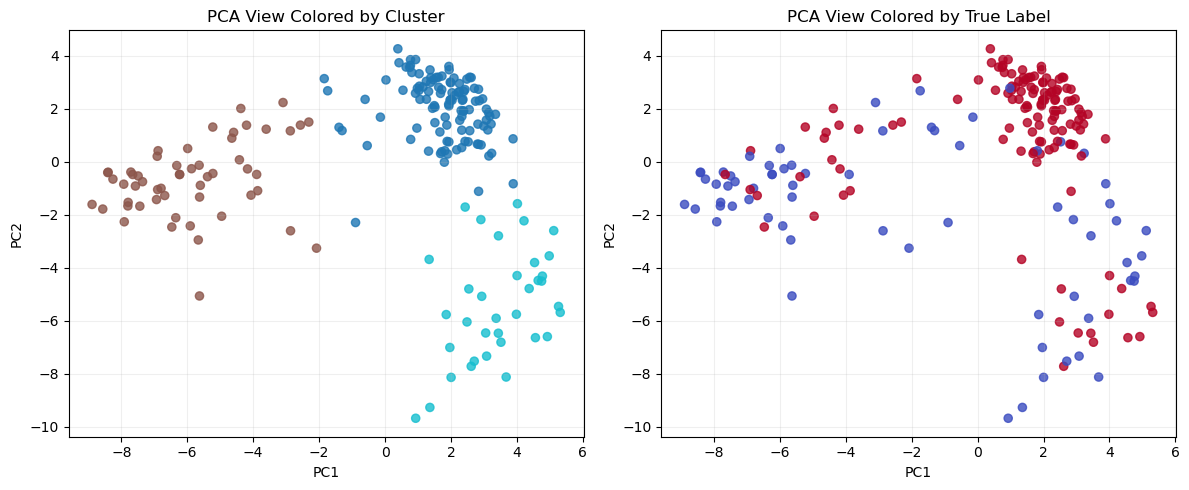

In [13]:
# 2D projection for visual inspection
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_used)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, s=35, cmap='tab10', alpha=0.8)
axes[0].set_title('PCA View Colored by Cluster')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.2)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, s=35, cmap='coolwarm', alpha=0.8)
axes[1].set_title('PCA View Colored by True Label')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Surrogate tree train fidelity: 0.985
Surrogate tree CV fidelity: 0.94

Surrogate rules:

|--- t_41 <= -0.60
|   |--- class: 1
|--- t_41 >  -0.60
|   |--- t_30 <= -1.45
|   |   |--- t_12 <= -0.76
|   |   |   |--- class: 0
|   |   |--- t_12 >  -0.76
|   |   |   |--- class: 0
|   |--- t_30 >  -1.45
|   |   |--- t_30 <= -0.70
|   |   |   |--- class: 2
|   |   |--- t_30 >  -0.70
|   |   |   |--- class: 2



,feature,importance
41,t_41,0.570841
30,t_30,0.427106
12,t_12,0.002053
2,t_2,0.000000
4,t_4,0.000000
5,t_5,0.000000
6,t_6,0.000000
0,t_0,0.000000
7,t_7,0.000000
8,t_8,0.000000


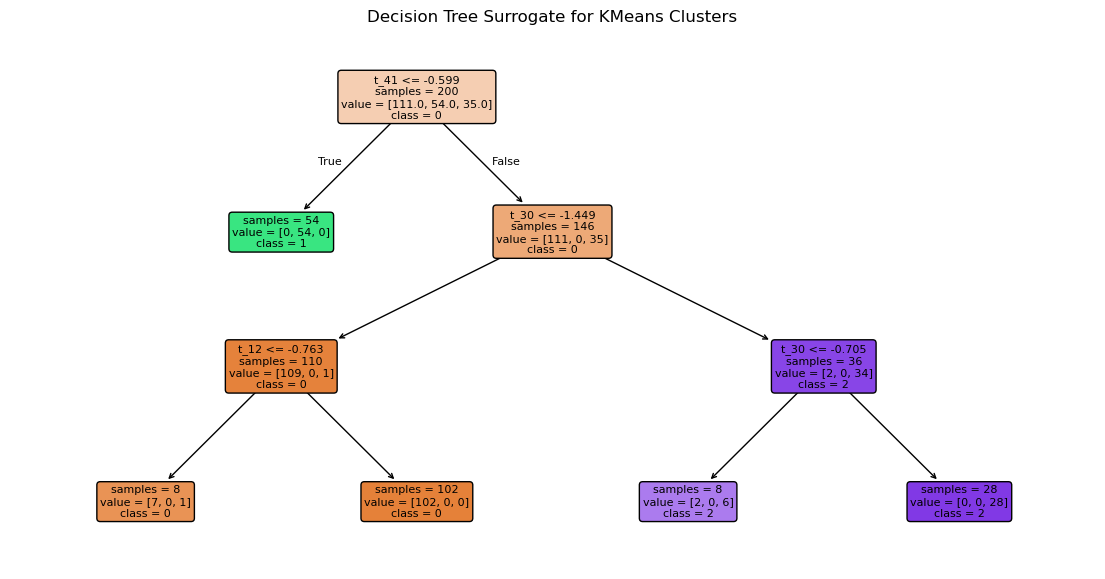

In [14]:
# Train a shallow decision tree as a surrogate explainer for KMeans clusters
feature_names = [f't_{i}' for i in range(X_used.shape[1])]

surrogate = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=42)
surrogate.fit(X_used, cluster_labels)

surrogate_pred = surrogate.predict(X_used)
train_fidelity = accuracy_score(cluster_labels, surrogate_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_fidelity = cross_val_score(
    surrogate, X_used, cluster_labels, cv=cv, scoring='accuracy'
).mean()

print('Surrogate tree train fidelity:', round(float(train_fidelity), 4))
print('Surrogate tree CV fidelity:', round(float(cv_fidelity), 4))

rules = export_text(surrogate, feature_names=feature_names)
print('\nSurrogate rules:\n')
print(rules)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': surrogate.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(14, 7))
plot_tree(
    surrogate,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(np.unique(cluster_labels))],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
    )
plt.title('Decision Tree Surrogate for KMeans Clusters')
plt.show()

## Why KMeans can be explainable

KMeans is prototype-based: each cluster has a centroid, and each sample is assigned to the nearest centroid in Euclidean distance. This is interpretable through centroid shapes and distance-to-centroid logic.

A practical way to explain assignments is to train a shallow surrogate model (for example, a decision tree) to predict KMeans cluster labels from the same features. High surrogate fidelity means the tree captures most of KMeans behavior in readable rules.